### 24RB1075 小嶋将太郎

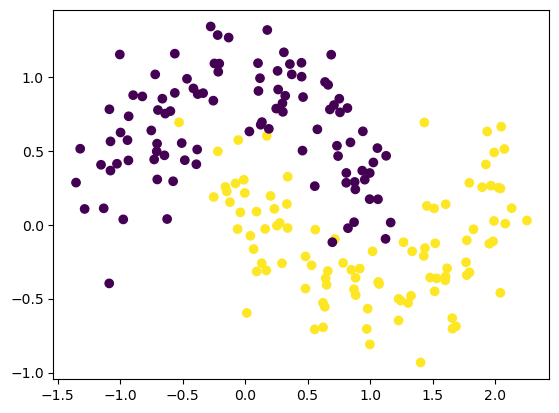

In [35]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=200, noise=0.2, random_state=0)
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()


In [36]:
"""決定木（分類木）の実装雛形．

第6回 演習「決定木の実装」用の雛形．`# TODO` を埋めて完成させること．

使い方の例：

    import numpy as np
    from decision_tree import DecisionTreeClassifier

    X = ...  # shape (m, n) の特徴量
    y = ...  # shape (m,) のクラスラベル（0, 1, ..., K-1 を想定）

    clf = DecisionTreeClassifier(max_depth=3, criterion="gini")
    clf.fit(X, y)
    pred = clf.predict(X)
"""

from __future__ import annotations

import numpy as np


# ============================================================
# ノード
# ============================================================
class Node:
    """決定木の1ノード．内部ノードと葉ノードを単一クラスで表現する．

    - 内部ノード：``feature_id`` / ``threshold`` / ``left`` / ``right`` を埋める．
    - 葉ノード：``label`` / ``proba`` を埋める（``left``，``right`` は ``None`` のまま）．
    """

    def __init__(self) -> None:
        self.feature_id: int | None = None
        self.threshold: float | None = None
        self.left: "Node | None" = None
        self.right: "Node | None" = None
        self.label: int | None = None
        self.proba: np.ndarray | None = None

    def is_leaf(self) -> bool:
        return self.left is None and self.right is None


# ============================================================
# 決定木分類器（sklearn 風）
# ============================================================
class DecisionTreeClassifier:
    """``fit`` / ``predict`` を備えた決定木分類器．

    すべての処理（不純度計算・最良分割・再帰的な木の構築・予測）を
    このクラスのメソッドとして実装する．
    """

    def __init__(
        self,
        max_depth: int = 5,
        min_samples: int = 2,
        criterion: str = "gini",
    ) -> None:
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.criterion = criterion
        self.root: Node | None = None

    # --------------------------------------------------------
    # 不純度
    # --------------------------------------------------------
    def _impurity(self, y: np.ndarray) -> float:
        """``self.criterion`` に従って不純度を返す（Gini または Entropy）．"""
        if self.criterion == "gini":
            return self._gini(y)
        if self.criterion == "entropy":
            return self._entropy(y)
        raise ValueError(f"unknown criterion: {self.criterion!r}")

    @staticmethod
    def _gini(y: np.ndarray) -> float:
        """Gini 不純度 :math:`1 - \\sum_c p_c^2` を返す．"""
        # TODO: ラベル配列 y から各クラスの割合 p_c を求め，Gini 不純度を計算する
        classes, counts = np.unique(y, return_counts=True)
        p_c = counts / len(y)
        gini_impurity =  1 - np.sum(p_c ** 2)
        return gini_impurity

    @staticmethod
    def _entropy(y: np.ndarray) -> float:
        """エントロピー :math:`-\\sum_c p_c \\log_2 p_c` を返す．"""
        # TODO: ラベル配列 y から各クラスの割合 p_c を求め，エントロピーを計算する
        # ヒント：p_c = 0 のとき 0 log 0 = 0 とする
        classes, counts = np.unique(y, return_counts=True)
        p_c = counts / len(y)
        entropy = -np.sum(p_c * np.log2(p_c)) if np.all(p_c > 0) else 0
        return entropy

    # --------------------------------------------------------
    # 最良分割
    # --------------------------------------------------------
    def _best_split(
        self,
        X: np.ndarray,
        y: np.ndarray,
    ) -> tuple[int | None, float | None, float]:
        """情報利得が最大になる ``(feature_id, threshold, gain)`` を返す．

        分割が見つからない（または利得が 0 以下）の場合は ``(None, None, 0.0)``．
        """
        # TODO:
        # 1. 親ノードの不純度 ell(S) を self._impurity(y) で計算
        # 2. すべての特徴 j について：
        #    - X[:, j] のユニーク値の中間点を閾値候補にする
        #    - 各閾値 s で y を S^1 (x_j <= s), S^2 (x_j > s) に分割
        #    - 情報利得 ell(S) - |S^1|/|S| ell(S^1) - |S^2|/|S| ell(S^2) を計算
        # 3. 情報利得が最大の (j, s, gain) を返す
        ell_S = self._impurity(y)
        
        best_gain = 0.0
        best_feature_id = None
        best_threshold = None

        len_S = len(y)
        n_features = X.shape[1]

        for j in range(n_features):
            unique_values = np.unique(X[:, j])
            if len(unique_values) < 2:
                continue
            thresholds = (unique_values[:-1] + unique_values[1:]) / 2
            
            for s in thresholds:
                mask1 = X[:, j] <= s
                S1 = y[mask1]

                mask2 = X[:, j] > s
                S2 = y[mask2]

                len_S1 = len(S1)
                len_S2 = len(S2)

                ell_S1 = self._impurity(S1)
                ell_S2 = self._impurity(S2)

                gain = ell_S - (len_S1 / len_S) * ell_S1 - (len_S2 / len_S) * ell_S2

                if gain > best_gain:
                    best_gain = gain
                    best_feature_id = j
                    best_threshold = s
        
        return best_feature_id, best_threshold, best_gain

    # --------------------------------------------------------
    # 木の構築（再帰）
    # --------------------------------------------------------
    def _build_tree(self, X: np.ndarray, y: np.ndarray, depth: int = 0) -> Node:
        """データ ``(X, y)`` から ``Node`` を再帰的に構築する．"""
        node = Node()

        # TODO: 葉にする停止条件を判定し，葉なら label / proba を埋めて return
        #   例：depth >= self.max_depth, len(y) < self.min_samples,
        #       len(np.unique(y)) == 1
        if depth >= self.max_depth or len(y) < self.min_samples or len(np.unique(y)) == 1:
            counts = np.bincount(y)
            node.proba = counts / len(y)
            node.label = int(np.argmax(counts))
            return node

        # TODO: self._best_split(X, y) を呼ぶ．分割が得られなければ葉にして return
        j, s, gain = self._best_split(X, y)
        if j is None:
            counts = np.bincount(y)
            node.proba = counts / len(y)
            node.label = int(np.argmax(counts))
            return node

        # TODO: 分割が得られたら子ノードを再帰的に構築：
        #   node.feature_id, node.threshold = j, s
        #   node.left  = self._build_tree(X[left_mask],  y[left_mask],  depth + 1)
        #   node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        node.feature_id, node.threshold = j, s
        left_mask = X[:, j] <= s
        right_mask = X[:, j] > s

        node.left = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        node.right = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        return node

    # --------------------------------------------------------
    # 予測
    # --------------------------------------------------------
    def _predict_one(self, x: np.ndarray) -> int:
        """単一サンプル ``x`` の予測ラベルを返す（``self.root`` から辿る）．"""
        # TODO: self.root から始め，葉に到達するまで
        #   x[node.feature_id] <= node.threshold で left/right に降りる
        node = self.root

        while not node.is_leaf():
            if x[node.feature_id] <= node.threshold:
                node = node.left
            else:
                node = node.right
        # TODO: 葉に到達したら node.label を返す
        return node.label
    
    # --------------------------------------------------------
    # 公開 API（sklearn 互換）
    # --------------------------------------------------------
    def fit(self, X: np.ndarray, y: np.ndarray) -> "DecisionTreeClassifier":
        """訓練データから決定木を学習する．"""
        self.root = self._build_tree(X, y, depth=0)
        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """``X`` の各行に対する予測ラベルの配列を返す．"""
        assert self.root is not None, "fit() を呼んでから predict() してください"
        return np.array([self._predict_one(x) for x in X])


In [46]:
def plot(clf, X, y, depth, title="Decision Tree depth={depth}"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    h = 0.05
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    mesh_points = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(mesh_points)

    Z = Z.reshape(xx.shape)
    plt.figsize = (8, 6)
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.title(title.format(depth=depth))
    plt.xlabel("Feature 0")
    plt.ylabel("Feature 1")
    plt.show()


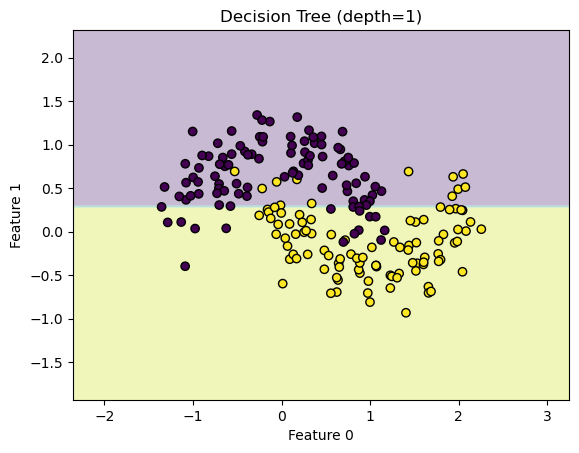

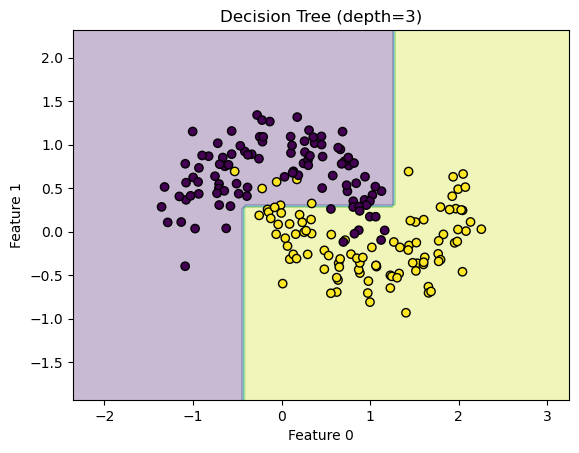

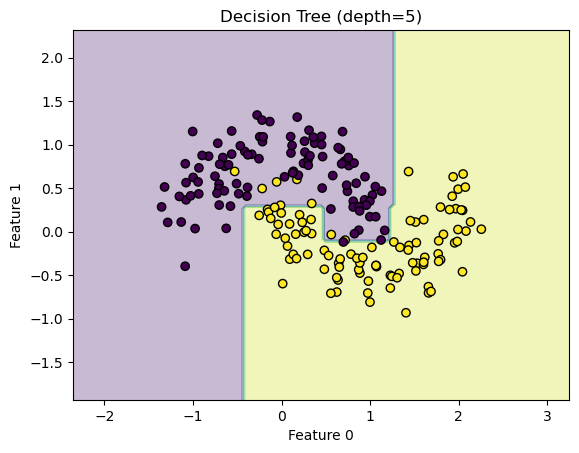

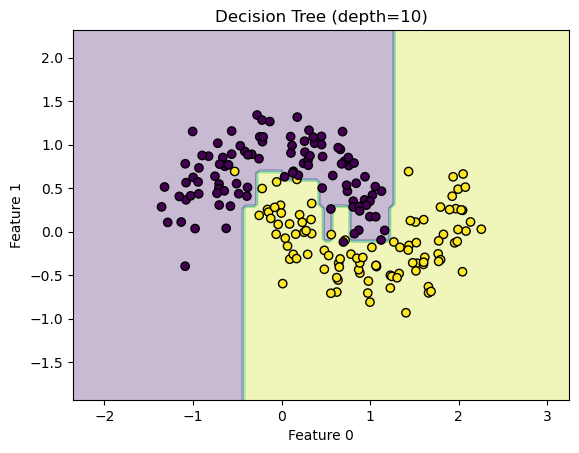

In [47]:
for depth in [1, 3, 5, 10]:
    # 自作の決定木クラスをインスタンス化
    clf = DecisionTreeClassifier(max_depth=depth, criterion="gini")
    
    # 学習
    clf.fit(X, y)
    
    # 決定境界の描画
    plot(clf, X, y, depth, title=f"Decision Tree (depth={depth})")

### 考察
三日月型データを用いた決定木の実装から、木の深さと決定境界の形状について関係性が見られた。深さを増すと特徴的な分布を捉えられているが、過剰に深くすると、ごく少数のデータのみ満たす条件分岐が生まれてしまい、ノイズに対して過剰適合した歪な決定境界が引かれていた。剪定などにより適切な深さを決定し、最適化する工夫が重要だと思った。

### AIの使用
複雑な部分に対して、雛形の手順を示しヒントを得た。その際、なるべく自分の手でプログラムを書くように注意した。描画方法の理解にも活用した。